# Daily Athlete Data Analysis

This notebook explores the merged Fitbit, PMSYS, Google Docs, and nutrition data, including preprocessing, the performance index, and the modeling targets. Meal categories and calories are estimated from photo timestamps; the project does not use a computer-vision model to recognize food. Calorie estimates are scaled to target an average of about 3,500 kcal per participant-day in this dataset and are not measured nutritional values.

The `injury_next_7d` target indicates whether an injury is recorded within seven days after an observation. `performance_index_next_day` is the performance index on the participant's next recorded observation, which is not necessarily the next calendar day.

The Python scripts are numbered in processing order: `1_nutrition.py`, `2_merge_dataset.py`, `3_features.py`, and `4_train_model.py`, followed by `5_eda.py` for exploratory analysis. `src/run_pipeline.py` runs the first four stages automatically. `meal_clustering.py` is a standalone script.

In [45]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    recall_score,
    r2_score,
    roc_auc_score,
)

plt.style.use('seaborn-v0_8-whitegrid')
COLORS = {'p01': '#1565C0', 'p03': '#00897B', 'p05': '#EF6C00'}
DATA_DIR = Path('..') / 'data' / 'processed'
df = pd.read_csv(DATA_DIR / 'test_dataset.csv', parse_dates=['date'])
df.head()

,participant_id,date,num_meals,total_calories_consumed,meal_types,image_names,calories_burned,distance,steps,heart_rate_mean,...,sleep_hours_7d_avg,training_load_7d_avg,readiness_7d_avg,training_load_7d_sum,training_load_28d_avg,acwr,injury_event,injury_next_7d,performance_index,performance_index_next_day
0,p01,2019-11-01,5.0,5382.0,NaN,NaN,4009.10,1442400.0,17873.0,0.0,...,5.841667,280.0,5.000000,280.0,280.0,0.142857,0,0,58.33,60.00
1,p01,2019-11-02,5.0,5382.0,NaN,NaN,3533.56,1058480.0,13118.0,0.0,...,6.070833,280.0,5.500000,560.0,280.0,0.285714,0,0,60.00,54.17
2,p01,2019-11-03,5.0,5382.0,NaN,NaN,3748.73,1146085.0,14312.0,0.0,...,6.147222,280.0,6.166667,840.0,280.0,0.428571,0,0,54.17,54.17
3,p01,2019-11-04,5.0,5382.0,NaN,NaN,3353.38,885970.0,10970.0,0.0,...,6.114583,280.0,6.500000,1120.0,280.0,0.571429,0,0,54.17,50.00
4,p01,2019-11-05,5.0,5382.0,NaN,NaN,3794.63,1371470.0,16186.0,0.0,...,5.978333,266.0,6.700000,1330.0,266.0,0.714286,0,0,50.00,50.00


## Dataset Structure and Missing Values

Dimensions : (456, 74)


float64           38
int64             32
str                3
datetime64[us]     1
Name: count, dtype: int64

,missing_percent
meal_types,65.4
image_names,65.4
performance_index_next_day,0.7


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
participant_id,456,3,p01,152,NaN,NaN,NaN,NaN,NaN,NaN,NaN
date,456,NaN,NaN,NaN,2020-01-15 12:00:00,2019-11-01 00:00:00,2019-12-08 18:00:00,2020-01-15 12:00:00,2020-02-22 06:00:00,2020-03-31 00:00:00,NaN
num_meals,456.0,NaN,NaN,NaN,3.524123,1.0,2.0,3.0,5.0,9.5,1.767991
total_calories_consumed,456.0,NaN,NaN,NaN,3499.828947,345.0,2230.0,2397.0,5382.0,10110.0,1883.230958
meal_types,158,24,"Petit-déjeuner, Déjeuner, Collation / Encas, D...",19,NaN,NaN,NaN,NaN,NaN,NaN,NaN
image_names,158,158,"IMG_8916.jpeg, IMG_8917.jpeg, IMG_8918.jpeg, I...",1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
calories_burned,456.0,NaN,NaN,NaN,3168.261571,1929.6,2725.245,3271.085,3672.0175,5092.17625,723.086884
distance,456.0,NaN,NaN,NaN,763735.039474,0.0,485405.0,778850.0,1000320.0,1772692.5,392567.156511
steps,456.0,NaN,NaN,NaN,9825.166118,0.0,6280.0,10116.5,13115.75,23369.375,4975.129915
heart_rate_mean,456.0,NaN,NaN,NaN,0.0,0.0,0.0,0.0,0.0,0.0,0.0


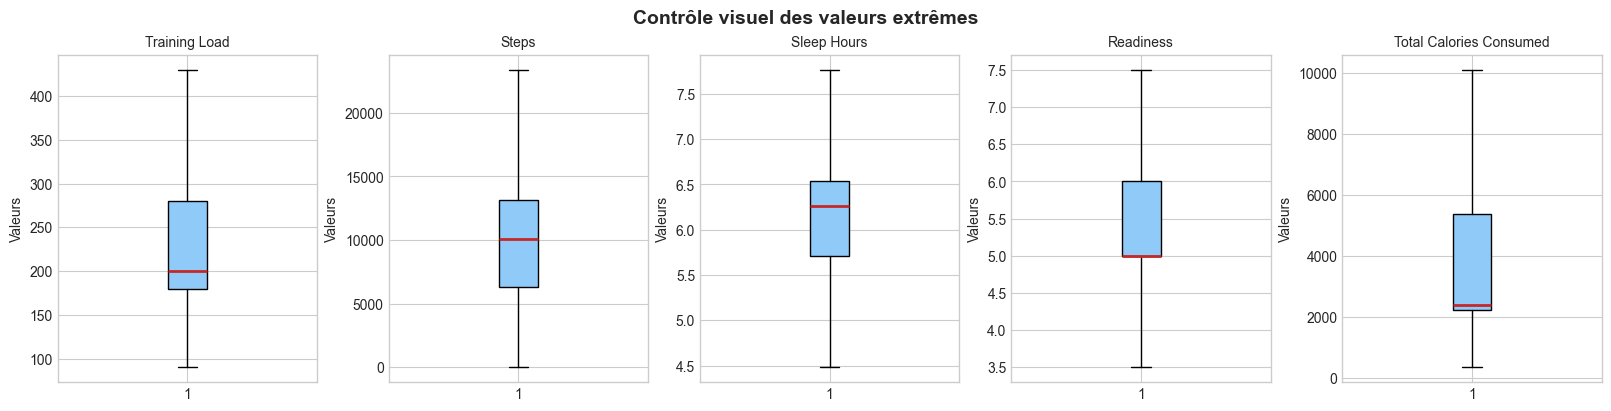

In [31]:
print('Dimensions :', df.shape) # (nb tuples, Attributs)

display(df.dtypes.value_counts())
missing = (df.isna().mean().sort_values(ascending=False) * 100).round(1)
display(missing[missing > 0].head(15).to_frame('missing_percent'))
display(df.describe(include='all').T.head(20))

numeric_to_check = [column for column in ['training_load', 'steps', 'sleep_hours', 'readiness', 'total_calories_consumed'] if column in df]
fig, axes = plt.subplots(1, len(numeric_to_check), figsize=(16, 4), constrained_layout=True)
for axis, column in zip(axes, numeric_to_check):
    axis.boxplot(df[column].dropna(), patch_artist=True,
                 boxprops={'facecolor': '#90CAF9'}, medianprops={'color': '#C62828', 'linewidth': 2})
    axis.set_title(column.replace('_', ' ').title(), fontsize=10)
    axis.set_ylabel('Valeurs')
fig.suptitle('Contrôle visuel des valeurs extrêmes', fontsize=14, fontweight='bold')
plt.show()

## Performance Index and Injury Risk

The `performance_index` is a composite score from 0 to 100, averaging the available readiness, sleep quality and duration, mood, fatigue, and soreness components.

The `injury_next_7d` target is 1 if an injury is recorded within seven days after the current date.

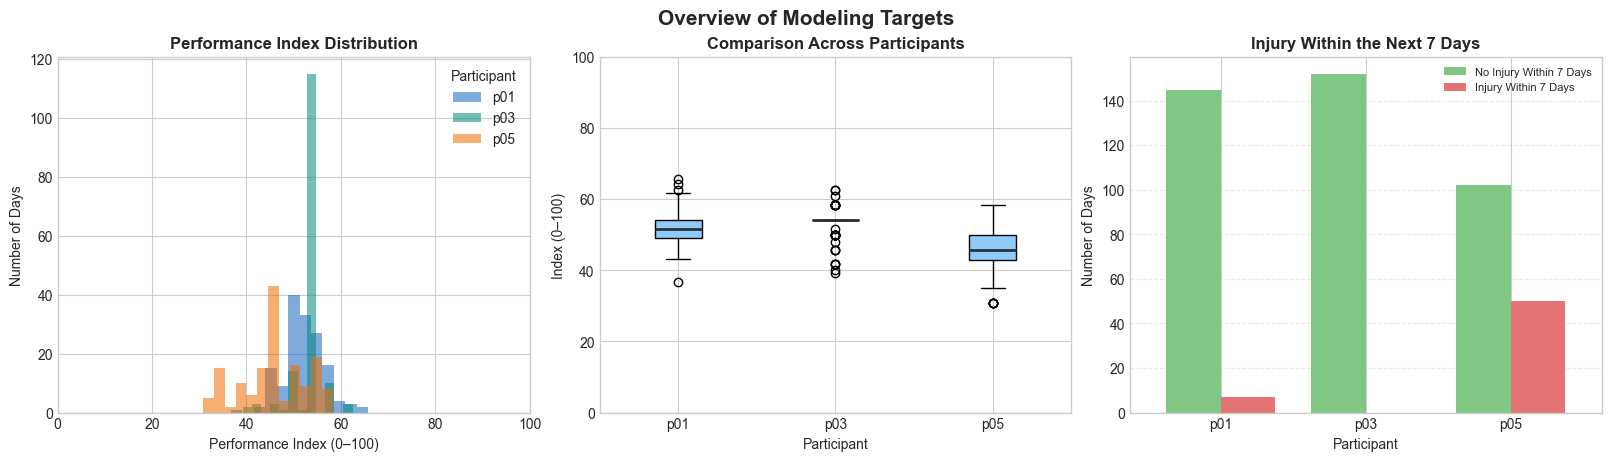

In [48]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5), constrained_layout=True)

for participant_id, group in df.groupby('participant_id'):
    axes[0].hist(group['performance_index'], bins=12, alpha=0.55,
                 color=COLORS.get(participant_id, '#455A64'), label=participant_id)
axes[0].set_title('Performance Index Distribution', fontweight='bold')
axes[0].set_xlabel('Performance Index (0–100)')
axes[0].set_ylabel('Number of Days')
axes[0].legend(title='Participant', frameon=False)
axes[0].set_xlim(0, 100)

box_data = [df.loc[df['participant_id'] == participant_id, 'performance_index']
            for participant_id in sorted(df['participant_id'].unique())]
axes[1].boxplot(box_data, tick_labels=sorted(df['participant_id'].unique()), patch_artist=True,
                boxprops={'facecolor': '#90CAF9'}, medianprops={'color': '#263238', 'linewidth': 2})
axes[1].set_title('Comparison Across Participants', fontweight='bold')
axes[1].set_xlabel('Participant')
axes[1].set_ylabel('Index (0–100)')
axes[1].set_ylim(0, 100)

risk_counts = df.groupby(['participant_id', 'injury_next_7d']).size().unstack(fill_value=0)
risk_counts.rename(columns={0: 'No Injury Within 7 Days', 1: 'Injury Within 7 Days'}).plot(
    kind='bar', ax=axes[2], color=['#81C784', '#E57373'], width=0.75)
axes[2].set_title('Injury Within the Next 7 Days', fontweight='bold')
axes[2].set_xlabel('Participant')
axes[2].set_ylabel('Number of Days')
axes[2].tick_params(axis='x', rotation=0)
axes[2].legend(frameon=False, fontsize=8)
axes[2].grid(axis='y', linestyle='--', alpha=0.4)

fig.suptitle('Overview of Modeling Targets', fontsize=15, fontweight='bold')
plt.show()

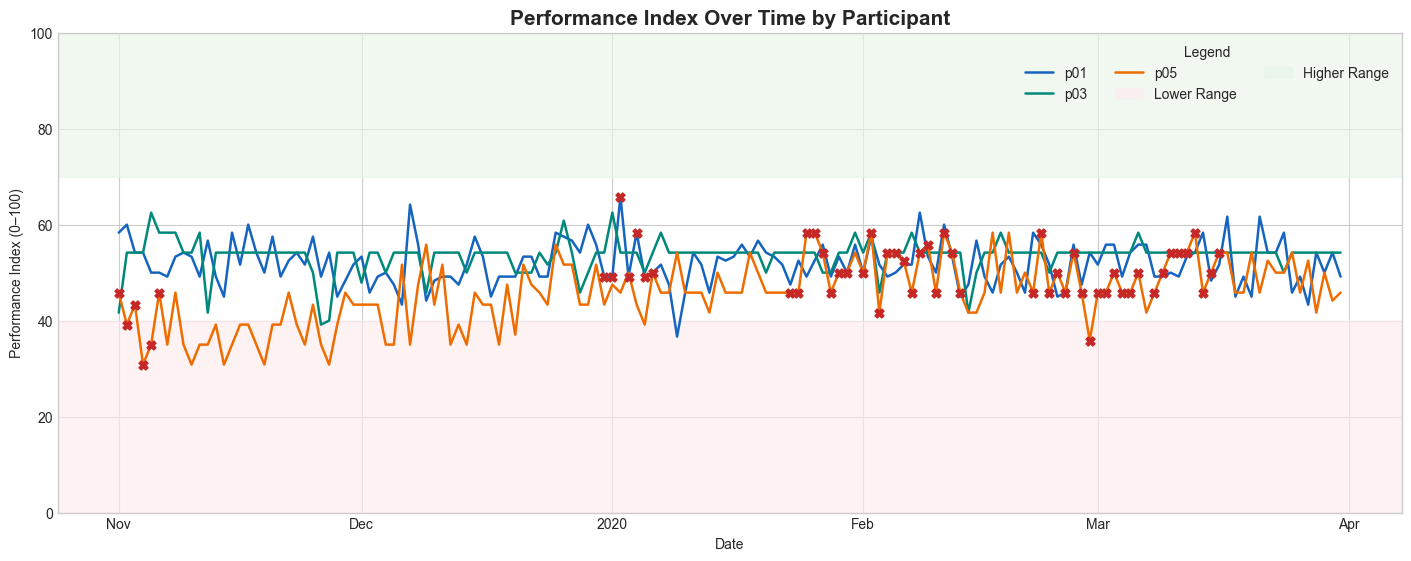

In [50]:
plot_df = df[df['date'].between('2019-11-01', '2020-03-31')].copy()
fig, ax = plt.subplots(figsize=(14, 5.5), constrained_layout=True)
for participant_id, group in plot_df.groupby('participant_id'):
    group = group.sort_values('date')
    ax.plot(
        group['date'], group['performance_index'],
        color=COLORS.get(participant_id, '#455A64'), linewidth=1.8,
        label=participant_id,
    )
    injury_days = group[group['injury_next_7d'].eq(1)]
    ax.scatter(
        injury_days['date'], injury_days['performance_index'],
        color='#C62828', marker='X', s=42, zorder=3,
    )
ax.axhspan(0, 40, color='#FFEBEE', alpha=0.65, label='Lower Range')
ax.axhspan(70, 100, color='#E8F5E9', alpha=0.65, label='Higher Range')
ax.set_title('Performance Index Over Time by Participant', fontsize=15, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Performance Index (0–100)')
ax.set_ylim(0, 100)
locator = mdates.AutoDateLocator(minticks=5, maxticks=8)
ax.xaxis.set_major_locator(locator)
ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))
ax.legend(title='Legend', ncol=3, frameon=False)
plt.show()

## Rationale and Limitations

The performance index is a composite score from 0 to 100. It combines readiness (0–10), sleep quality, sleep duration, mood, fatigue, and soreness. These recovery dimensions are consistent with research on training load and recovery. Equal weights keep the score interpretable and avoid claiming to estimate scientifically validated coefficients from only three participants.

The model predicts the index for the participant's next recorded observation using information available on the current date. This avoids directly reusing the variables that make up the current day's index as the target. The next observation is not necessarily the next calendar day.

The injury model is evaluated using precision, recall, F1-score, ROC-AUC, and PR-AUC. Recall matters because it measures how many injury cases are detected; PR-AUC is included because injury-risk days are a minority. Performance predictions are evaluated using MAE, RMSE, and R². The split is chronological: each participant's most recent 20% of dates are used for testing.

References: Banister & Calvert (1980), *Planning for future performance: implications for long term training*; Foster et al. (2001), *A new approach to monitoring exercise training*; Gabbett (2016), *The training-injury prevention paradox*.

Limitations: the index is an exploratory proxy, not a clinical measure; photo-based calorie estimates are heuristic and calibrated only to a dataset-level average; the models should not be used to make medical decisions.

## Model Results

The models use a chronological split: each participant's most recent 20% of dates are held out for testing.

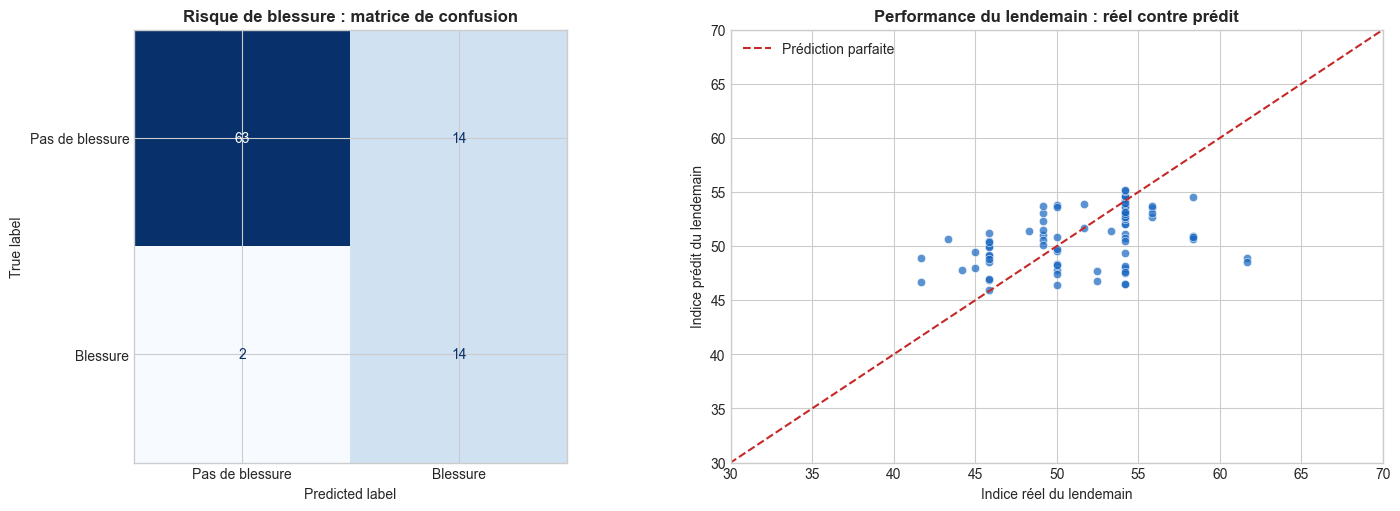

,valeur
Blessure - précision,0.500
Blessure - rappel,0.875
Blessure - F1,0.636
Blessure - ROC-AUC,0.929
Blessure - PR-AUC,0.719
Performance - MAE,2.902
Performance - RMSE,3.917
Performance - R²,0.118


,participant_id,date,injury_next_7d,injury_probability,performance_target,performance_prediction
0,p01,2020-02-29,0,0.072511,51.67,53.886699
1,p01,2020-03-01,0,0.071981,55.83,53.507204
2,p01,2020-03-02,0,0.113064,55.83,52.673423
3,p01,2020-03-03,0,0.258644,49.17,51.070610
4,p01,2020-03-04,0,0.066524,54.17,53.700560
5,p01,2020-03-05,0,0.049877,55.83,53.080805
6,p01,2020-03-06,0,0.230843,55.83,53.752821
7,p01,2020-03-07,0,0.081511,49.17,53.087947
8,p01,2020-03-08,0,0.163394,49.17,52.369100
9,p01,2020-03-09,0,0.168566,50.00,50.805978


In [49]:
predictions_path = DATA_DIR / 'model_test_predictions.csv'
predictions = pd.read_csv(predictions_path, parse_dates=['date'])

y_true = predictions['injury_next_7d'].astype(int)
y_pred = predictions['injury_prediction'].astype(int)
injury_probability = predictions['injury_probability']
performance_target = predictions['performance_target']
performance_prediction = predictions['performance_prediction']
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

fig, axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)
ConfusionMatrixDisplay(cm, display_labels=['Pas de blessure', 'Blessure']).plot(
    ax=axes[0], cmap='Blues', colorbar=False, values_format='d')
axes[0].set_title('Risque de blessure : matrice de confusion', fontweight='bold')

axes[1].scatter(performance_target, performance_prediction,
                color='#1565C0', alpha=0.7, edgecolor='white', linewidth=0.5)
axes[1].plot([0, 100], [0, 100], '--', color='#C62828', linewidth=1.5, label='Prédiction parfaite')
axes[1].set_title('Performance du lendemain : réel contre prédit', fontweight='bold')
axes[1].set_xlabel('Indice réel du lendemain')
axes[1].set_ylabel('Indice prédit du lendemain')
axes[1].set_xlim(30, 70)
axes[1].set_ylim(30, 70)
axes[1].legend(frameon=False)
plt.show()

metrics = pd.Series({
    'Blessure - précision': precision_score(y_true, y_pred, zero_division=0),
    'Blessure - rappel': recall_score(y_true, y_pred, zero_division=0),
    'Blessure - F1': f1_score(y_true, y_pred, zero_division=0),
    'Blessure - ROC-AUC': roc_auc_score(y_true, injury_probability),
    'Blessure - PR-AUC': average_precision_score(y_true, injury_probability),
    'Performance - MAE': mean_absolute_error(performance_target, performance_prediction),
    'Performance - RMSE': mean_squared_error(performance_target, performance_prediction) ** 0.5,
    'Performance - R²': r2_score(performance_target, performance_prediction),
}).round(3)
display(metrics.to_frame('valeur'))
display(predictions[['participant_id', 'date', 'injury_next_7d', 'injury_probability',
                     'performance_target', 'performance_prediction']].head(10))